#HW2 - Clinical Trials Analytics in MongoDB

As a preface to this notebook, we must specify that due to a lack of cloud resources and thus insufficient storage memory, a reduced version of the `dimensions_clinicalTrials` dataset has been produced. This reduction also involved the preliminary removal of duplicates.

## 1. Pymongo and dependencies installation

To use MongoDB with Python, we need to install the PyMongo library.

In [ ]:
!pip install pymongo

We'll use Mongo Atlas to store the data for our analytics. To do this, we need to connect to the database using MongoClient and the URI provided by Mongo Atlas. This URI has been stored in the Colab environment.

In [ ]:
import csv, pymongo, re
from datetime import datetime

from google.colab import userdata
#MONGODB_URI = userdata.get('MONGODB_URI')
MONGODB_URI = userdata.get('MONGO_C_URI')

# Dataset Name and collection name
DB_NAME = "clinical_trials_db"
COLLECTION_NAME = "clinical_trials"

csvPath = "/content/dimensions_clinicalTrials_filtered.csv"

## 2. Preprocessing Functions

Some columns have pseudo-structured data, like dictionaries and lists. In particular:

**Lists**

*   Conditions
*   Investigators/Contacts
*   Sponsors/Collaborators
*   City of Sponsor/Collaborator
*   State of Sponsor/Collaborator
*   Country of Sponsor/Collaborator
*   Fields of Research (ANZSRC 2020)
*   Collaborating Funders
*   Funder Group
*   Funder Country
*   RCDC Categories
*   HRCS HC Categories
*   HRCS RAC Categories
*   Cancer Types
*   CSO Categories

**List of two elements**

*   Age (min ; max)

For better analytics, we have changed manually the type of these columns with a preprocessing script.

In [ ]:
def split_field_to_array(value, delimiter=";"):
    """
    Splits a string by a given delimiter into a list of stripped strings.
    Returns an empty list if the input value is None.
    """
    if value is None:
        return []
    return [item.strip() for item in value.split(delimiter)]

def parse_age_to_object(age_string):
    """
    Parses an age string (e.g., "10 years - 12 months") into a dictionary
    containing 'min_years' and 'max_years' (both in years).
    Handles 'None' or 'n/a' inputs gracefully.
    """
    min_age_val, max_age_val = None, None
    if not age_string or age_string.strip().lower() == "n/a - n/a":
        return {"min_years": None, "max_years": None}
    parts = [p.strip() for p in age_string.split('-')]

    # Subfunction for converting month/week/day/hour values in year values
    def convert_to_years(value_part_str):
        if "n/a" in value_part_str.lower():
          return None
        num_match = re.search(r'(\d+\.?\d*)\s*(year|years|month|months|week|weeks|day|days|hour|hours)', value_part_str, re.IGNORECASE)
        if not num_match:
          return None

        num = float(num_match.group(1)); unit = num_match.group(2).lower()
        if "year" in unit:
          return num
        elif "month" in unit:
          return num / 12
        elif "week" in unit:
          return num / 52
        elif "day" in unit:
          return num / 365
        elif "hour" in unit:
          return num / (365 * 24)
        return None

    if len(parts) > 0:
      min_age_val = convert_to_years(parts[0])
    if len(parts) > 1:
      max_age_val = convert_to_years(parts[1])

    return {"min_years": min_age_val, "max_years": max_age_val}

def to_datetime_or_null(date_string, fmt="%Y-%m-%d"):
    """
    Converts a date string to a datetime object using a specified format.
    Returns None if the string is empty, null, or cannot be parsed.
    """
    if not date_string or date_string.strip() == "": return None
    try: return datetime.strptime(date_string.strip(), fmt)
    except ValueError: return None

def to_int_or_null(value):
    """
    Converts a value to an integer. Returns None if the value is empty, null,
    or cannot be converted (e.g., non-numeric string).
    Handles float-like strings by converting to float first, then int.
    """
    if value is None or str(value).strip() == "": return None
    try: return int(float(str(value).strip()))
    except ValueError: return None

def to_float_or_null(value):
    """
    Converts a value to a float. Returns None if the value is empty, null,
    or cannot be converted (e.g., non-numeric string).
    """
    if value is None or str(value).strip() == "": return None
    try: return float(str(value).strip())
    except ValueError: return None

## 3. Dataset Load

This load_data_to_mongodb function orchestrates the entire data ingestion process. It leverages Python's `csv.DictReader` to iterate through each row of a CSV file, treating column headers as dictionary keys. For every row, a suite of custom preprocessing functions (`split_field_to_array, parse_age_to_object, to_datetime_or_null, to_int_or_null, to_float_or_null`) is applied to clean and transform raw string values into appropriate data types and structures (e.g., lists, datetime objects, nested dictionaries for age ranges). This meticulously prepared document_payload is then used in a PyMongo update_one operation with upsert=True, ensuring that existing records are updated and new ones are inserted based on the Trial ID as the unique identifier (_id).

In [ ]:
def load_data_to_mongodb(client):
  db = client[DB_NAME]
  collection = db[COLLECTION_NAME]

  processed_count = 0
  upserted_count = 0
  matched_count = 0

  with open(csvPath, 'r', encoding='utf-8') as csvfile:
      reader = csv.DictReader(csvfile)
      print(f"Nomi colonne rilevati: {reader.fieldnames}")

      for i, row_data in enumerate(reader):
        try:
          trial_id_csv = row_data.get("Trial ID")
          if not trial_id_csv:
            print(f"Riga {i+1} saltata: Trial ID mancante.")
            continue

          sponsors_info = []
          sponsor_names = split_field_to_array(row_data.get("Sponsors/Collaborators", ""))
          sponsor_cities = split_field_to_array(row_data.get("City of Sponsor/Collaborator", ""))
          sponsor_states = split_field_to_array(row_data.get("State of Sponsor/Collaborator", ""))
          sponsor_countries = split_field_to_array(row_data.get("Country of Sponsor/Collaborator", ""))
          num_sponsors = len(sponsor_names)
          for k in range(num_sponsors):
              if sponsor_names[k]:
                  info = {"name": sponsor_names[k]}
                  if k < len(sponsor_cities) and sponsor_cities[k]: info["city"] = sponsor_cities[k]
                  if k < len(sponsor_states) and sponsor_states[k]: info["state"] = sponsor_states[k]
                  if k < len(sponsor_countries) and sponsor_countries[k]: info["country"] = sponsor_countries[k]
                  sponsors_info.append(info)

          funders_info = []
          funder_names = split_field_to_array(row_data.get("Collaborating Funders", ""))
          funder_countries_list = split_field_to_array(row_data.get("Funder Country", ""))
          num_funders = len(funder_names)
          for k in range(num_funders):
              if funder_names[k]:
                  info = {"name": funder_names[k]}
                  if k < len(funder_countries_list) and funder_countries_list[k]: info["country"] = funder_countries_list[k]
                  funders_info.append(info)

          document_payload = {
              "rank": to_int_or_null(row_data.get("Rank")),
              "title": row_data.get("Title"),
              "brief_title": row_data.get("Brief title"),
              "acronym": row_data.get("Acronym") or None,
              "abstract": row_data.get("Abstract") or None,
              "start_date": to_datetime_or_null(row_data.get("Start date")),
              "start_year": to_int_or_null(row_data.get("Start Year")),
              "end_date": to_datetime_or_null(row_data.get("End Date")),
              "completion_year": to_int_or_null(row_data.get("Completion Year")),
              "phase": row_data.get("Phase") or None,
              "study_type": row_data.get("Study Type") or None,
              "conditions": split_field_to_array(row_data.get("Conditions", "")),
              "recruitment_status": row_data.get("Recruitment Status") or None,
              "number_of_participants": to_int_or_null(row_data.get("Number of Participants")),
              "intervention": row_data.get("Intervention") or None,
              "gender": row_data.get("Gender") or None,
              "age_details": parse_age_to_object(row_data.get("Age", "")),
              "registry": row_data.get("Registry") or None,
              "investigators_contacts": split_field_to_array(row_data.get("Investigators/Contacts", "")),
              "sponsors_collaborators_info": sponsors_info,
              "collaborating_funders_info": funders_info,
              "funder_groups": split_field_to_array(row_data.get("Funder Group", "")),
              "source_linkout": row_data.get("Source Linkout") or None,
              "altmetric_attention_score": to_float_or_null(row_data.get("Altmetric Attention Score")),
              "dimensions_url": row_data.get("Dimension URL") or None,
              "fields_of_research_anzsrc2020": split_field_to_array(row_data.get("Fields of Research (ANZSRC 2020)", "")),
              "rcdc_categories": split_field_to_array(row_data.get("RCDC Categories", "")),
              "hrcs_hc_categories": split_field_to_array(row_data.get("HRCS HC Categories", "")),
              "hrcs_rac_categories": split_field_to_array(row_data.get("HRCS RAC Categories", "")),
              "cancer_types": split_field_to_array(row_data.get("Cancer Types", "")),
              "cso_categories": split_field_to_array(row_data.get("CSO Categories", "")),
              "ahc": split_field_to_array(row_data.get("AHC", ""))
          }

          # Esegui upsert per ogni documento
          result = collection.update_one(
              {"_id": trial_id_csv},
              {"$set": document_payload},
              upsert=True
          )

          processed_count += 1
          if result.upserted_id:
              upserted_count += 1
          elif result.matched_count > 0:
              matched_count += 1

          # Stampa un progresso ogni N record (es. ogni 100)
          if processed_count % 100 == 0:
              print(f"Processati {processed_count} record. Nuovi inseriti (upserted): {upserted_count}, Esistenti aggiornati (matched): {matched_count}.")

        except Exception as e:
              print(f"Errore alla riga {i+1} del CSV (Trial ID: {row_data.get('Trial ID', 'ID SCONOSCIUTO')}): {e}")
              print(f"Dati riga problematica: {row_data}")
              continue


In [ ]:
mongo_client = None
try:
  mongo_client = pymongo.MongoClient(MONGODB_URI)
  mongo_client.admin.command('ping')
  print("Connessione a MongoDB Atlas riuscita")

  load_data_to_mongodb(mongo_client)

except Exception as e:
    print(f"Errore generale durante l'esecuzione: {e}")
finally:
    if mongo_client:
        mongo_client.close()
        print("Connessione a MongoDB chiusa.")

Connessione a MongoDB Atlas riuscita
Nomi colonne rilevati: ['Rank', 'Trial ID', 'Title', 'Brief title', 'Acronym', 'Abstract', 'Start date', 'Start Year', 'End Date', 'Completion Year', 'Phase', 'Study Type', 'Study Design', 'Conditions', 'Recruitment Status', 'Number of Participants', 'Intervention', 'Gender', 'Age', 'Registry', 'Investigators/Contacts', 'Sponsors/Collaborators', 'City of Sponsor/Collaborator', 'State of Sponsor/Collaborator', 'Country of Sponsor/Collaborator', 'Collaborating Funders', 'Funder Group', 'Funder Country', 'Source Linkout', 'Altmetric Attention Score', 'Dimensions URL', 'Fields of Research (ANZSRC 2020)', 'RCDC Categories', 'HRCS HC Categories', 'HRCS RAC Categories', 'Cancer Types', 'CSO Categories', 'AHC']
Processati 100 record. Nuovi inseriti (upserted): 100, Esistenti aggiornati (matched): 0.
Processati 200 record. Nuovi inseriti (upserted): 200, Esistenti aggiornati (matched): 0.
Processati 300 record. Nuovi inseriti (upserted): 300, Esistenti aggio

## 4. Analytics

In [ ]:
import pandas as pd

client = pymongo.MongoClient(MONGODB_URI)
db = client[DB_NAME]
collection = db[COLLECTION_NAME]

1. Number of studies initiated by year

In [ ]:
pipeline_1 = [
    {
        "$match": {
            "start_year": {"$ne": None}
        }
    },
    {
        "$group": {
            "_id": "$start_year",
            "num_studies": {"$sum": 1}
        }
    },
    {
        "$sort": {"_id": 1}
    }
]
result_1 = list(collection.aggregate(pipeline_1))

if result_1:
  df_1 = pd.DataFrame(result_1)
  df_1.rename(columns={'_id': 'Anno', 'num_studies': 'Numero Studi'}, inplace=True)

  print(df_1)
else:
  print("Nessun risultato")

csv_1 = "mongo_1.csv"
df_1.to_csv(csv_1, index=False, encoding='utf-8-sig')

    Anno  Numero Studi
0   1987             1
1   1991             1
2   1992             2
3   1993             2
4   1994             3
5   1995             4
6   1996             2
7   1997             4
8   1998             8
9   1999             4
10  2000            19
11  2001            21
12  2002            22
13  2003            31
14  2004            50
15  2005            58
16  2006            91
17  2007           114
18  2008           149
19  2009           159
20  2010           173
21  2011           193
22  2012           242
23  2013           215
24  2014           233
25  2015           280
26  2016           283
27  2017           349
28  2018           360
29  2019           406
30  2020           421
31  2021           453
32  2022           368
33  2023           242
34  2024            22
35  2025             2


2. Average number of participants per study

In [ ]:
pipeline_2 = [
    {
        "$match": {
            "title": {"$ne": None},
            "number_of_participants": {"$ne": None}
        }
    },
    {
        "$group": {
            "_id": "$title",
            "avg_participants": {"$avg": "$number_of_participants"}
        }
    },
    {
        "$sort": {"avg_participants": -1}
    },
    {
        "$limit": 20
    }
]

results_2 = list(collection.aggregate(pipeline_2))

if results_2:
  df_2 = pd.DataFrame(results_2)
  df_2.rename(columns={'_id': 'Titolo Studio', 'avg_participants': 'Media Partecipanti'}, inplace=True)

  print(df_2)
else:
  print("Nessun risultato")

csv_2 = "mongo_2.csv"
df_2.to_csv(csv_2, index=False, encoding='utf-8-sig')

                                        Titolo Studio  Media Partecipanti
0   The epidemiology, severity, and outcomes of ch...           2400000.0
1   ACCESS template protocol for safety of COVID-1...           1000000.0
2   Computerized Registry of Patients With Venous ...            120000.0
3   Effect of Pharmacist Involvement on Patient Re...            115000.0
4   What is the Best Interval to Screen Women 45-4...             60000.0
5   Cohort Event Monitoring of safety of COVID-19 ...             60000.0
6   International Randomized Study Comparing Perso...             53142.0
7   PRospective Evaluation of the European Society...             52156.0
8   DianaWeb: Before and After Study Online Based ...             50000.0
9   A Multicenter, Cross-sectional Study to Charac...             39480.0
10  Evaluation and Improvement of the Health-care ...             39000.0
11  Observational Post-marketing Study on the Safe...             35921.0
12  Antibiotic Prophylaxis for Catarac

Top 10 most studied medical conditions

In [ ]:
pipeline_3 = [
    {
        "$unwind": "$conditions"
    },
    {
        "$match": {
            "conditions": {"$ne": None, "$ne": ""}
        }
    },
    {
        "$group": {
            "_id": "$conditions",
            "count": {"$sum": 1}
        }
    },
    {
        "$sort": {"count": -1}
    },
    {
        "$limit": 10
    }
]

results_3 = list(collection.aggregate(pipeline_3))

if results_3:
  df_3 = pd.DataFrame(results_3)
  df_3.rename(columns={'_id': 'Condizione', 'count': 'Conteggio'}, inplace=True)

  print(df_3)
else:
  print("Nessun risultato")

csv_3 = "mongo_3.csv"
df_3.to_csv(csv_3, index=False, encoding='utf-8-sig')

                  Condizione  Conteggio
0              Breast Cancer         82
1    Coronary Artery Disease         67
2           Multiple Myeloma         59
3              Heart Failure         46
4         Ulcerative Colitis         42
5  Myelodysplastic Syndromes         35
6                Lung Cancer         34
7            Prostate Cancer         33
8     Acute Myeloid Leukemia         33
9            Crohn's Disease         31


Nation with the highest average number of participants, by type of study

In [ ]:
pipeline_4 = [
    {
        "$unwind": "$sponsors_collaborators_info"
    },
    {
        "$match": {
            "study_type": {"$ne": None, "$ne": "", "$ne": "null"},
            "sponsors_collaborators_info.country": {"$ne": None, "$ne": "", "$ne": "null"},
            "number_of_participants": {"$ne": None, "$ne": "null", "$type": "number"}
        }
    },
    {
        "$group": {
            "_id": {
                "study_type": "$study_type",
                "country": "$sponsors_collaborators_info.country"
            },
            "avg_participants": {"$avg": "$number_of_participants"}
        }
    },
    {
        "$sort": {
            "_id.study_type": 1,
            "avg_participants": -1
        }
    },
    {
        "$group": {
            "_id": "$_id.study_type",
            "top_country": {"$first": "$_id.country"},
            "highest_avg_participants": {"$first": "$avg_participants"}
        }
    },
    {
        "$sort": {"_id": 1}
    }
]

results_4 = list(collection.aggregate(pipeline_4))

if results_4:
  df_4 = pd.DataFrame(results_4)
  df_4.rename(columns={'_id': 'Tipo di Studio', 'top_country': 'Top Paese', 'highest_avg_participants': 'Media Partecipanti più Alta'}, inplace=True)

  print(df_4)
else:
  print("Nessun risultato")

csv_4 = "mongo_4.csv"
df_4.to_csv(csv_4, index=False, encoding='utf-8-sig')

        Tipo di Studio Top Paese  Media Partecipanti più Alta
0  Active surveillance     Italy                115000.000000
1                  CCT     Egypt                   520.000000
2       Interventional   Iceland                  8962.500000
3   Non-interventional     Italy                    17.000000
4        Observational   Iceland                804333.333333


5. Cities that have dealt most with a particular condition

In [ ]:
collection.create_index("conditions")
collection.create_index("sponsors_collaborators_info.city")

'sponsors_collaborators_info.city_1'

In [ ]:
pipeline_5 = [
    {"$unwind": "$conditions"},
    {"$unwind": "$sponsors_collaborators_info"},
    {
        "$match": {
            "conditions": {"$type": "string", "$ne": ""},
            "sponsors_collaborators_info.city": {"$type": "string", "$ne": ""}
        }
    },
    {
        "$group": {
            "_id": {
                "condition": {"$toLower": "$conditions"},
                "city": {"$toLower":"$sponsors_collaborators_info.city"}
            },
            "num_studies": {"$sum": 1}
        }
    },
    {
        "$sort": {
            "_id.condition": 1,
            "num_studies": -1
        }
    },
    {
        "$group": {
            "_id": "$_id.condition",
            "top_city": {"$first": "$_id.city"},
            "studies_in_top_city": {"$first": "$num_studies"}
        }
    },
    {"$match": {"studies_in_top_city": {"$gt": 1}}},
    {"$sort": {"studies_in_top_city": -1}},
    {"$limit": 20}
]

results_5 = list(collection.aggregate(pipeline_5, allowDiskUse=True))

if results_5:
  df_5 = pd.DataFrame(results_5)
  df_5.rename(columns={'_id': 'Condizione', 'top_city': 'Top Città', 'studies_in_top_city': 'Studi in Top Città'}, inplace=True)

  print(df_5)
else:
  print("Nessun risultato")

csv_5 = "mongo_5.csv"
df_5.to_csv(csv_5, index=False, encoding='utf-8-sig')

                        Condizione  Top Città  Studi in Top Città
0                    breast cancer     madrid                 124
1               ulcerative colitis      seoul                 117
2                         leukemia       rome                  99
3       non-small cell lung cancer     madrid                  92
4                  crohn's disease      seoul                  90
5                   gastric cancer      seoul                  74
6         stage iiia breast cancer  las vegas                  71
7                 multiple myeloma     madrid                  70
8     stage iv lung cancer ajcc v8  las vegas                  66
9        invasive breast carcinoma  las vegas                  64
10  carcinoma, non-small-cell lung      seoul                  62
11       myelodysplastic syndromes       rome                  61
12             atrial fibrillation     madrid                  59
13          stage ii breast cancer  las vegas                  57
14        

6.  Nations sponsoring the largest number of clinical trials targeting women

In [ ]:
pipeline_6 = [
    {
        "$match": {
            "gender": "Female"
        }
    },
    {
        "$unwind": "$sponsors_collaborators_info"
    },
    {
        "$match": {
            "sponsors_collaborators_info.country": {"$type": "string", "$ne": ""}
        }
    },
    {
        "$group": {
            "_id":{"$toLower": "$sponsors_collaborators_info.country"},
            "num_studies": {"$sum": 1}
        }
    },
    {
        "$sort": {"num_studies": -1}
    },
    {
        "$limit": 10
    }
]

results_6 = list(collection.aggregate(pipeline_6))

if results_6:
  df_6 = pd.DataFrame(results_6)
  df_6.rename(columns={'_id': 'Paese', 'num_studies': 'Numero Studi'}, inplace=True)

  print(df_6)
else:
  print("Nessun risultato")

csv_6 = "mongo_6.csv"
df_6.to_csv(csv_6, index=False, encoding='utf-8-sig')

            Paese  Numero Studi
0   united states          8028
1           italy          2230
2           spain           688
3         germany           590
4          france           453
5          canada           318
6  united kingdom           318
7          poland           274
8         belgium           269
9           japan           243


7. Nations sponsoring the largest number of studies involving minors

In [ ]:
pipeline_7 = [
    {
        "$match": {
            "age_details.min_years": {"$ne": None, "$lt": 18}
        }
    },
    {
        "$unwind": "$sponsors_collaborators_info"
    },
    {
        "$match": {
            "sponsors_collaborators_info.country": {"$type": "string", "$ne": ""}
        }
    },
    {
        "$group": {
            "_id": {"$toLower": "$sponsors_collaborators_info.country"},
            "num_studies": {"$sum": 1}
        }
    },
    {
        "$sort": {"num_studies": -1}
    },
    {
        "$limit": 10
    }
]

results_7 = list(collection.aggregate(pipeline_7))

if results_7:
  df_7 = pd.DataFrame(results_7)
  df_7.rename(columns={'_id': 'Paese', 'num_studies': 'Numero Studi'}, inplace=True)

  print(df_7)
else:
  print("Nessun risultato")

csv_7 = "mongo_7.csv"
df_7.to_csv(csv_7, index=False, encoding='utf-8-sig')

            Paese  Numero Studi
0   united states          7987
1           italy          3079
2         germany          1679
3           spain          1462
4          france          1444
5           japan          1179
6  united kingdom          1090
7          poland          1032
8          canada           785
9       australia           686


8. Cities most actively researching a specific type of cancer

In [ ]:
pipeline_8 = [
    {"$unwind": "$cancer_types"},
    {"$unwind": "$sponsors_collaborators_info"},
    {
        "$match":{
            "cancer_types": {"$type": "string", "$ne": ""},
            "sponsors_collaborators_info.city": {"$type": "string", "$ne": ""}
        }
    },
    {
        "$group": {
            "_id": {
                "cancer_type": {"$toLower": "$cancer_types"},
                "city": {"$toLower": "$sponsors_collaborators_info.city"}
            },
            "num_studies": {"$sum": 1}
        }
    },
    {
        "$sort": {
            "_id.cancer_type": 1,
            "num_studies": -1
        }
    },
    {
        "$group": {
            "_id": "$_id.cancer_type",
            "top_city": {"$first": "$_id.city"},
            "studies_in_top_city": {"$first": "$num_studies"}
        }
    },
    {
        "$match": {"studies_in_top_city": {"$gte": 20}}
    },
    {
        "$sort": {"studies_in_top_city": -1}
    },
    {
        "$limit": 20
    }
]

results_8 = list(collection.aggregate(pipeline_8))

if results_8:
  df_8 = pd.DataFrame(results_8)
  df_8.rename(columns={'_id': 'Tipo di Cancro', 'top_city': 'Top Città', 'studies_in_top_city': 'Studi in Top Città'}, inplace=True)
  print(df_8)
else:
  print("Nessun risultato")

csv_8 = "mongo_8.csv"
df_8.to_csv(csv_8, index=False, encoding='utf-8-sig')

              Tipo di Cancro  Top Città  Studi in Top Città
0       leukemia / leukaemia       rome                 558
1                lung cancer     madrid                 368
2     non-hodgkin's lymphoma      milan                 296
3              breast cancer     madrid                 287
4    colon and rectal cancer       rome                 168
5             stomach cancer      seoul                 110
6               liver cancer     london                  99
7                    myeloma       rome                  94
8                   melanoma  barcelona                  92
9          pancreatic cancer     verona                  89
10            bladder cancer      seoul                  86
11  not site-specific cancer     madrid                  85
12           prostate cancer   new york                  80
13              blood cancer       rome                  77
14             kidney cancer     madrid                  66
15            ovarian cancer      milan 

9. Clinical trials that have ended, with related medical conditions treated

In [ ]:
from datetime import datetime

current_date = datetime.now()

pipeline_9 = [
    {
        "$match": {
            "end_date": {"$ne": None, "$lt": current_date}
        }
    },
    {
        "$unwind": "$conditions"
    },
    {
        "$match": {
            "conditions": {"$type": "string", "$ne": ""}
        }
    },
    {
        "$project": {
            "_id": 0,
            "Trial ID": "$_id",
            "End Date": "$end_date",
            "Conditions": "$conditions"
        }
    },
    {
        "$sort": {"End Date": -1}
    },
    {
        "$limit": 20
    }
]

results_9 = list(collection.aggregate(pipeline_9))

if results_9:
  df_9 = pd.DataFrame(results_9)
  print(df_9)
else:
  print("Nessun risultato")

csv_9 = "mongo_9.csv"
df_9.to_csv(csv_9, index=False, encoding='utf-8-sig')

       Trial ID   End Date                                    Conditions
0   NCT05595642 2025-06-01  Chronic Obstructive Pulmonary Disease (COPD)
1   NCT05153239 2025-06-01               Relapsed Small Cell Lung Cancer
2   NCT06174636 2025-06-01          Respiratory Distress Syndrome, Adult
3   NCT03917173 2025-06-01                             Stomach Neoplasms
4   NCT05610280 2025-06-01                       Cardiovascular Diseases
5   NCT04591431 2025-06-01                    Non Small Cell Lung Cancer
6   NCT06174636 2025-06-01                           Respiratory Failure
7   NCT03994796 2025-06-01                             CDK Gene Mutation
8   NCT05876754 2025-06-01                            Cholangiocarcinoma
9   NCT03914820 2025-06-01                          Colorectal Neoplasms
10  NCT04591431 2025-06-01                                  Other Cancer
11  NCT05610280 2025-06-01                          Hypertriglyceridemia
12  NCT05535946 2025-06-01                         

10. Clinical trials with higher media visibility (Altmetric score)

In [ ]:
pipeline_10 = [
    {
        "$match": {
            "altmetric_attention_score": {"$ne": None, "$type": "number"}
        }
    },
    {
        "$unwind": "$conditions"
    },
    {
        "$match": {
            "conditions": {"$type": "string", "$ne": ""}
        }
    },
    {
        "$sort": {"altmetric_attention_score": -1}
    },
    {
        "$limit": 20
    },
    {
        "$project": {
            "_id": 0,
            "Trial ID": "$_id",
            "Title": "$title",
            "Altmetric Score": "$altmetric_attention_score",
            "Condtion": "$conditions"
        }
    }
]

results_10 = list(collection.aggregate(pipeline_10))

if results_10:
  df_10 = pd.DataFrame(results_10)
  print(df_10)
else:
  print("Nessun risultato")

csv_10 = "mongo_10.csv"
df_10.to_csv(csv_10, index=False, encoding='utf-8-sig')

       Trial ID                                              Title  \
0   NCT02819635  A Multicenter, Randomized, Double-Blind, Place...   
1   NCT03104400  A Phase 3, Randomized, Double-Blind, Study Com...   
2   NCT03105128  A Multicenter, Randomized, Double-Blind, Place...   
3   NCT04292899  A Phase 3 Randomized Study to Evaluate the Saf...   
4   NCT03398148  A Multicenter, Randomized, Double-Blind, Place...   
5   NCT03398135  A Multicenter, Randomized, Double-Blind, Place...   
6   NCT03569293  A Phase 3 Randomized, Placebo-Controlled, Doub...   
7   NCT03671148  A Phase 3, Randomized, Double-Blind Study Comp...   
8   NCT03345836  A Multicenter, Randomized, Double-Blind, Place...   
9   NCT03345823  A Multicenter, Randomized, Double-Blind, Place...   
10  NCT02811861  A Multicenter, Open-label, Randomized, Phase 3...   
11  NCT03173248  A Phase 3, Multicenter, Double-Blind, Randomiz...   
12  NCT03173248  A Phase 3, Multicenter, Double-Blind, Randomiz...   
13  NCT03173248  A P

11. Conditions with higher average Altmetric Score

In [ ]:
pipeline_11 = [
    {
        "$match": {
            "altmetric_attention_score": {"$ne": None, "$type": "number"}
        }
    },
    {
        "$unwind": "$conditions"
    },
    {
        "$match": {
            "conditions": {"$type": "string", "$ne": ""}
        }
    },
    {
        "$group": {
            "_id": {"$toLower": "$conditions"},
            "avg_altmetric_score": {"$avg": "$altmetric_attention_score"}
        }
    },
    {
        "$sort": {"avg_altmetric_score": -1}
    },
    {
        "$limit": 20
    },
    {
        "$project": {
            "_id": 0,
            "Condition": "$_id",
            "Average Altmetric Score": "$avg_altmetric_score"
        }
    }
]

results_10 = list(collection.aggregate(pipeline_11))

if results_10:
  df_11 = pd.DataFrame(results_10)
  print(df_11)
else:
  print("Nessun risultato")

csv_11 = "mongo_11.csv"
df_11.to_csv(csv_11, index=False, encoding='utf-8-sig')

                                          Condition  Average Altmetric Score
0                           ulcerative colitis (uc)                    985.0
1                         psoriatic arthritis (psa)                    962.0
2   aml arising from myelodysplastic syndrome (mds)                    834.0
3      newly diagnosed acute myeloid leukemia (aml)                    834.0
4                                     untreated aml                    834.0
5   kras p, g12c mutated /advanced metastatic nsclc                    788.0
6                                   breast diseases                    784.0
7                  central nervous system neoplasms                    784.0
8                                   brain neoplasms                    784.0
9                            retinal vein occlusion                    774.0
10        kirsten rat sarcoma (kras) pg12c mutation                    757.0
11                                   liver fibroses                    695.0

12. Nations of the funding organizations that sponsored the largest number of clinical trials

In [ ]:
pipeline_12 = [
    {
        "$unwind": "$collaborating_funders_info"
    },
    {
        "$match": {
            "collaborating_funders_info.country": {"$type": "string", "$ne": ""}
        }
    },
    {
        "$group": {
            "_id": {"$toLower": "$collaborating_funders_info.country"},
            "num_studies": {"$sum": 1}
        }
    },
    {
        "$sort": {"num_studies": -1}
    },
    {
        "$limit": 10
    },
    {
        "$project": {
            "_id": 0,
            "Country": "$_id",
            "Number of Studies": "$num_studies"
        }
    }
]

results_12 = list(collection.aggregate(pipeline_12))

if results_12:
  df_12 = pd.DataFrame(results_12)
  print(df_12)
else:
  print("Nessun risultato")

csv_12 = "mongo_12.csv"
df_12.to_csv(csv_12, index=False, encoding='utf-8-sig')

          Country  Number of Studies
0   united states               1159
1           italy               1048
2         germany                183
3           japan                140
4  united kingdom                116
5         belgium                 96
6     switzerland                 80
7     netherlands                 55
8          france                 43
9         denmark                 25


13. Most active researchers/contacts with related most studied pathology



In [ ]:
pipeline_13 = [
    {"$unwind": "$investigators_contacts"},
    {"$unwind": "$conditions"},
    {
        "$match": {
            "investigators_contacts": {"$type": "string", "$ne": ""},
            "conditions": {"$type": "string", "$ne": ""}
        }
    },
    {
        "$group": {
            "_id": {
                "investigator": {"$toLower": "$investigators_contacts"},
                "condition": {"$toLower": "$conditions"}
            },
            "num_studies_for_condition": {"$sum": 1}
        }
    },
    {
        "$sort": {
            "_id.investigator": 1,
            "num_studies_for_condition": -1
        }
    },
    {
        "$sort": {
            "_id.investigator": 1,
            "num_studies_for_condition": -1
        }
    },
    {
        "$group": {
            "_id": "$_id.investigator",
            "top_condition": {"$first": "$_id.condition"},
            "studies_for_top_condition": {"$first": "$num_studies_for_condition"},
            "total_studies_by_investigator": {"$sum": "$num_studies_for_condition"}
        }
    },
    {
        "$sort": {"total_studies_by_investigator": -1}
    },
    {
        "$limit": 20
    },
    {
        "$project": {
            "_id": 0,
            "Investigator": "$_id",
            "Total Studies": "$total_studies_by_investigator",
            "Top Condition": "$top_condition",
            "Studies for Top Condition": "$studies_for_top_condition"
        }
    }
]

results_13 = list(collection.aggregate(pipeline_13))

if results_13:
  df_13 = pd.DataFrame(results_13)
  print(df_13)
else:
  print("Nessun risultato")

csv_13 = "mongo_13.csv"
df_13.to_csv(csv_13, index=False, encoding='utf-8-sig')

           Investigator  Total Studies  \
0     jennifer a. dorth             82   
1      charles shideman             80   
2          tyler gunter             78   
3          jack j. hong             77   
4            abbvie inc             74   
5       bryan a. faller             73   
6     michael d. chuong             73   
7        jordan kharofa             73   
8           shane lloyd             73   
9      kathleen j. yost             68   
10       jay w. carlson             68   
11           steven lin             67   
12     benjamin spieler             67   
13   jason k. molitoris             67   
14    john m. robertson             67   
15    christian c. hyde             67   
16        jehee i. choi             67   
17  stephen a. mihalcik             67   
18        abraham j. wu             67   
19     mark w. mcdonald             67   

                                        Top Condition  \
0                  anal canal squamous cell carcinoma   
1  

14. Top collaborations of the University of Naples Federico II with funding bodies (Sponsor/Collaborator)

In [ ]:
federico_ii_ahc_name = "AOUSSN_FEDERICOII"

pipeline_14 = [
    {"$match": {"ahc": federico_ii_ahc_name}},
    {"$unwind": "$sponsors_collaborators_info"},
    {
        "$match": {
            "sponsors_collaborators_info.name": {"$type": "string", "$ne": ""}
        }
    },
    {
        "$group": {
            "_id": "$sponsors_collaborators_info.name",
            "num_collaborations": {"$sum": 1}
        }
    },
    {
        "$sort": {"num_collaborations": -1}
    },
    {
        "$limit": 20
    },
    {
        "$project": {
            "_id": 0,
            "Sponsor/Collaborator": "$_id",
            "Number of Collaborations": "$num_collaborations"
        }
    }
]

results_14 = list(collection.aggregate(pipeline_14))

if results_14:
  df_14 = pd.DataFrame(results_14)
  print(df_14)
else:
  print("Nessun risultato")

csv_14 = "mongo_14.csv"
df_14.to_csv(csv_14, index=False, encoding='utf-8-sig')

                                 Sponsor/Collaborator  \
0                     Federico II University Hospital   
1                            GSK Investigational Site   
2                                       Research Site   
3              Agostino Gemelli University Polyclinic   
4                 Vall d'Hebron Hospital Universitari   
5                         IRCCS Ospedale San Raffaele   
6           Azienda Ospedaliero-Universitaria Careggi   
7                           Spedali Civili di Brescia   
8   Azienda Ospedaliero Universitaria Ospedali Riu...   
9                Hospital Universitario Ramón y Cajal   
10            Hospital Universitario Virgen del Rocío   
11  Fondazione IRCCS Ca' Granda Ospedale Maggiore ...   
12           Azienda Ospedaliera Universitaria Pisana   
13                      Policlinico S.Orsola-Malpighi   
14                     Universitair Ziekenhuis Leuven   
15               Hospital Universitario 12 de Octubre   
16                       Hospit

16. Top collaboration by funding entity (Main Funder Group vs. Collaborating Funder Name)

In [ ]:
pipeline_16 = [
    {"$unwind": "$funder_groups"},
    {"$unwind": "$collaborating_funders_info"},
    {
        "$match": {
            "funder_groups": {"$type": "string", "$ne": ""},
            "collaborating_funders_info.name": {"$type": "string", "$ne": ""}
        }
    },
    {
        "$project": {
            "main_funder": {"$toLower": "$funder_groups"},
            "collaborating_funder": {"$toLower": "$collaborating_funders_info.name"}
        }
    },
    {
        "$match":{
            "$expr": {"$ne": ["$main_funder", "$collaborating_funder"]}
        }
    },
    {
        "$group": {
            "_id": {
                "main_funder": "$main_funder",
                "collaborating_funder": "$collaborating_funder"
            },
            "collab_count": {"$sum": 1}
        }
    },
    {
        "$sort": {
            "_id.main_funder": 1,
            "collab_count": -1
        }
    },
    {
        "$group": {
            "_id": "$_id.main_funder",
            "top_collaborating_funder": {"$first": "$_id.collaborating_funder"},
            "num_collaborations_with_top": {"$first": "$collab_count"}
        }
    },
    {
        "$sort": {"num_collaborations_with_top": -1}
    },
    {
        "$limit": 20
    },
    {
        "$project": {
            "_id": 0,
            "Main Funder Group": "$_id",
            "Top Collaborating Funder": "$top_collaborating_funder",
            "Number of Collaborations": "$num_collaborations_with_top"
        }
    }
]

results_16 = list(collection.aggregate(pipeline_16))

if results_16:
  df_16 = pd.DataFrame(results_16)
  print(df_16)
else:
  print("Nessun risultato")

csv_16 = "mongo_16.csv"
df_16.to_csv(csv_16, index=False, encoding='utf-8-sig')

                                  Main Funder Group  \
0                                us federal funders   
1  icrp - international cancer research partnership   
2               nih - national institutes of health   
3  amrc - association of medical research charities   
4                                       coalition s   
5                         ec & erc - european union   
6                    hra - health research alliance   
7     nihr - national institute for health research   
8         dod - united states department of defense   
9                 ukri - uk research and innovation   

                            Top Collaborating Funder  Number of Collaborations  
0                          national cancer institute                       105  
1                          national cancer institute                       105  
2                          national cancer institute                       105  
3  european organisation for research and treatme...                  

## 5. Visualization

In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Base path notebooks Colab
base_path = '/content/drive/MyDrive/Colab Notebooks'

# Complete path Big data directory
big_data_path = os.path.join(base_path, 'Big Data')

# Big data directory verification
if not os.path.exists(big_data_path):
    os.makedirs(big_data_path)
    print(f"Directory created: {big_data_path}")
else:
    print(f"The directory already exists: {big_data_path}")
    # Print directory if exists
    try:
        print("Big Data directory contents:")
        print(os.listdir(big_data_path))
    except:
        print("Unable to read the directory contents")

# Homework 2 path
homework2Path = os.path.join(big_data_path, "Homework 2")

# If HW 1 path exists
if not os.path.exists(homework2Path):
    os.makedirs(homework2Path)
    print(f"Directory created: {homework2Path}")
else:
    print(f"The directory already exists: {homework2Path}")

# Results path
resultPath = os.path.join(homework2Path, "Mongo_Results")

Mounted at /content/drive
The directory already exists: /content/drive/MyDrive/Colab Notebooks/Big Data
Big Data directory contents:
['Homework 1', 'Final_Project', 'Homework 2']
The directory already exists: /content/drive/MyDrive/Colab Notebooks/Big Data/Homework 2


In [ ]:
output_path = os.path.join(resultPath, "plot")

os.makedirs(output_path, exist_ok=True)

1. Number of studies started per year

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request


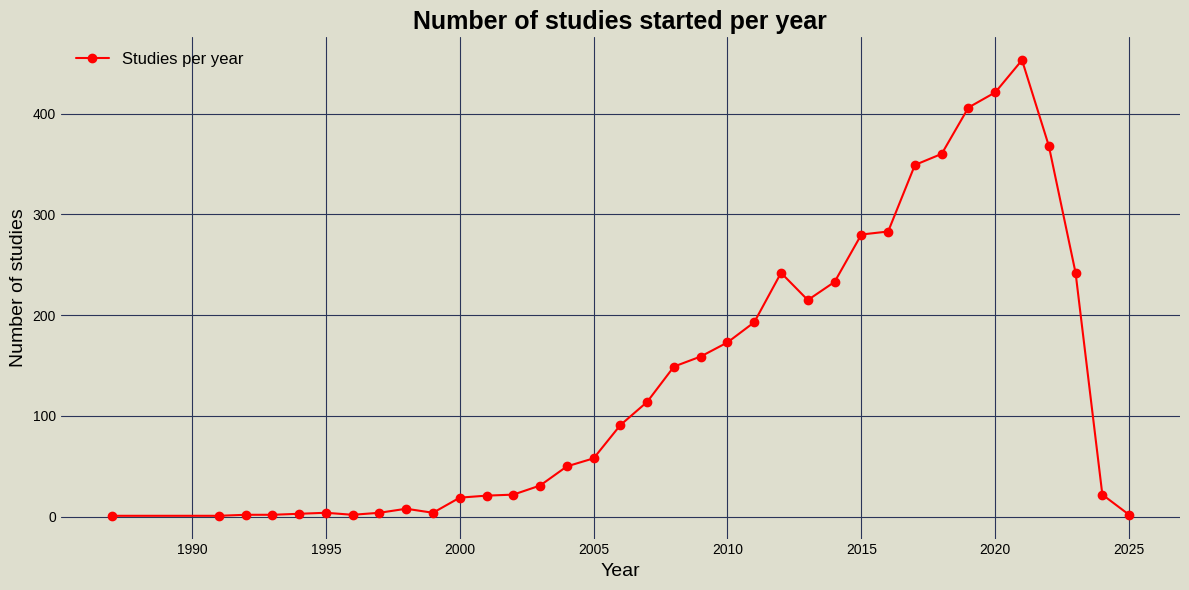

In [ ]:
df = pd.read_csv(resultPath+"/mongo_1.csv")
df = df.sort_values("Anno")

style_url = 'https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pitayasmoothie-dark.mplstyle'
style_path = 'pitayasmoothie-dark.mplstyle'

if not os.path.exists(style_path):
    urllib.request.urlretrieve(style_url, style_path)


plt.style.use(style_path)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#dedece')
ax.set_facecolor('#dedece')

ax.set_title("Number of studies started per year", fontsize=18, fontweight='bold', color='black')

ax.set_xlabel("Year", fontsize=14, color='black')
ax.set_ylabel("Number of studies", fontsize=14, color='black')

ax.tick_params(axis='x', labelsize=10, labelcolor='black')
ax.tick_params(axis='y', labelsize=10, labelcolor='black')

plt.plot(df["Anno"], df["Numero Studi"], marker='o', linestyle='-', color='red', label="Studies per year")
leg = ax.legend(facecolor='#eeeeee', edgecolor='black', fontsize=12, labelcolor='black')

image_file = os.path.join(output_path, "mongo_1.png")
plt.tight_layout()
plt.savefig(image_file, dpi=300, facecolor=fig.get_facecolor())

plt.show()

2. Average Participant per Clinical Study Title

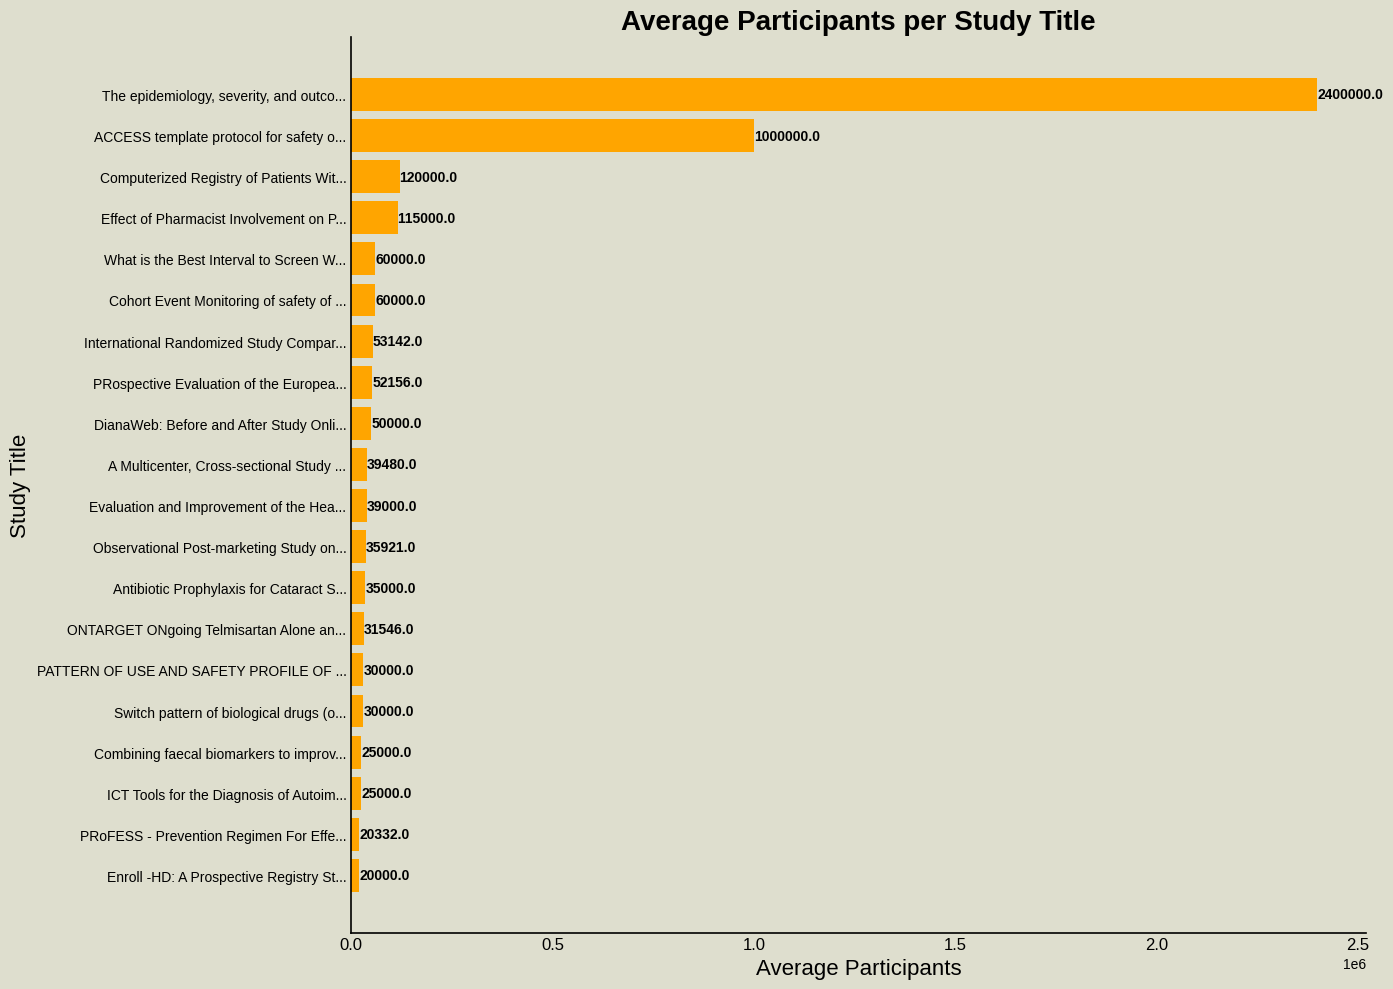

In [ ]:
df = pd.read_csv(os.path.join(resultPath, "mongo_2.csv"))


top_20 = df.head(20)


plt.style.use(style_path)

top_20 = top_20.sort_values('Media Partecipanti')

max_len = 40
top_20['Short Title'] = top_20['Titolo Studio'].apply(lambda x: x if len(x) <= max_len else x[:max_len - 3] + '...')

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('#dedece')
ax.set_facecolor('#dedece')

bars = ax.barh(top_20['Short Title'], top_20['Media Partecipanti'], color='orange')

for i, v in enumerate(top_20['Media Partecipanti']):
    ax.text(v + 5, i, f'{v:.1f}', va='center', fontsize=10, color='black', fontweight='bold')

ax.grid(False)

ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

ax.set_title("Average Participants per Study Title", fontsize=20, fontweight='bold', color='black')

ax.set_xlabel("Average Participants", fontsize=16, color='black')
ax.set_ylabel("Study Title", fontsize=16, color='black')

ax.tick_params(axis='x', labelsize=12, labelcolor='black')
ax.tick_params(axis='y', labelsize=10, labelcolor='black')

plt.tight_layout()

image_file = os.path.join(output_path, "mongo_2.png")
plt.savefig(image_file, dpi=300, facecolor=fig.get_facecolor())

plt.show()

3. Top 10 Most frequent Medical Condition

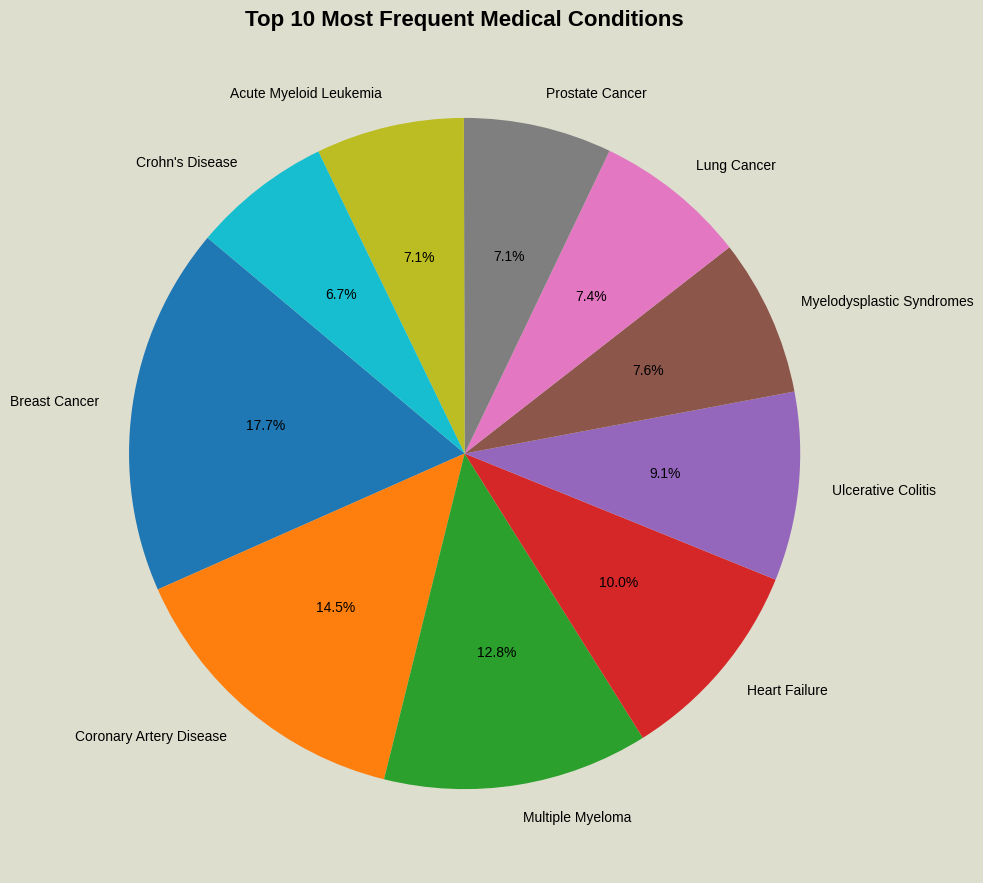

In [ ]:
df = pd.read_csv(os.path.join(resultPath, "mongo_3.csv"))

plt.style.use("ggplot")

labels = df['Condizione']
sizes = df['Conteggio']

colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(10, 10))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    textprops={'color': 'black', 'fontsize': 10}
)
fig.patch.set_facecolor('#dedece')

ax.set_title("Top 10 Most Frequent Medical Conditions", fontsize=16, fontweight='bold', color="black")

plt.tight_layout()

image_file = os.path.join(output_path, "mongo_3.png")
plt.savefig(image_file, dpi=300, facecolor=fig.get_facecolor())

plt.show()

4. Country with the most participants mean per Type of study

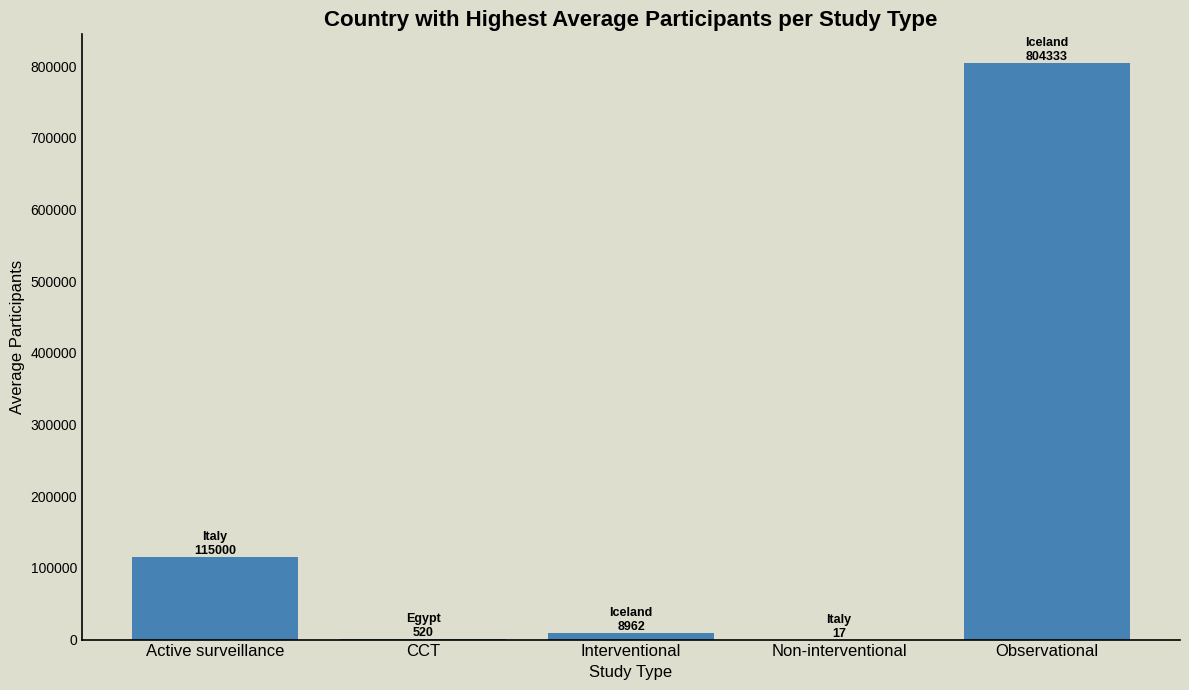

In [ ]:
df = pd.read_csv(os.path.join(resultPath, "mongo_4.csv"))

plt.style.use(style_path)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.bar(df["Tipo di Studio"], df["Media Partecipanti più Alta"], color='steelblue')
fig.patch.set_facecolor('#dedece')
ax.set_facecolor('#dedece')

for i, (val, country) in enumerate(zip(df["Media Partecipanti più Alta"], df["Top Paese"])):
    ax.text(i, val + 5, f"{country}\n{val:.0f}", ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')

ax.set_title("Country with Highest Average Participants per Study Type", fontsize=16, fontweight='bold', color='black')
ax.set_ylabel("Average Participants", fontsize=12, color='black')
ax.set_xlabel("Study Type", fontsize=12, color='black')

ax.grid(False)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

ax.tick_params(axis='x', labelsize=12, labelcolor='black')
ax.tick_params(axis='y', labelsize=10, labelcolor='black')

plt.tight_layout()

image_file = os.path.join(output_path, "mongo_4.png")
plt.savefig(image_file, dpi=300, facecolor=fig.get_facecolor())

plt.show()

6.

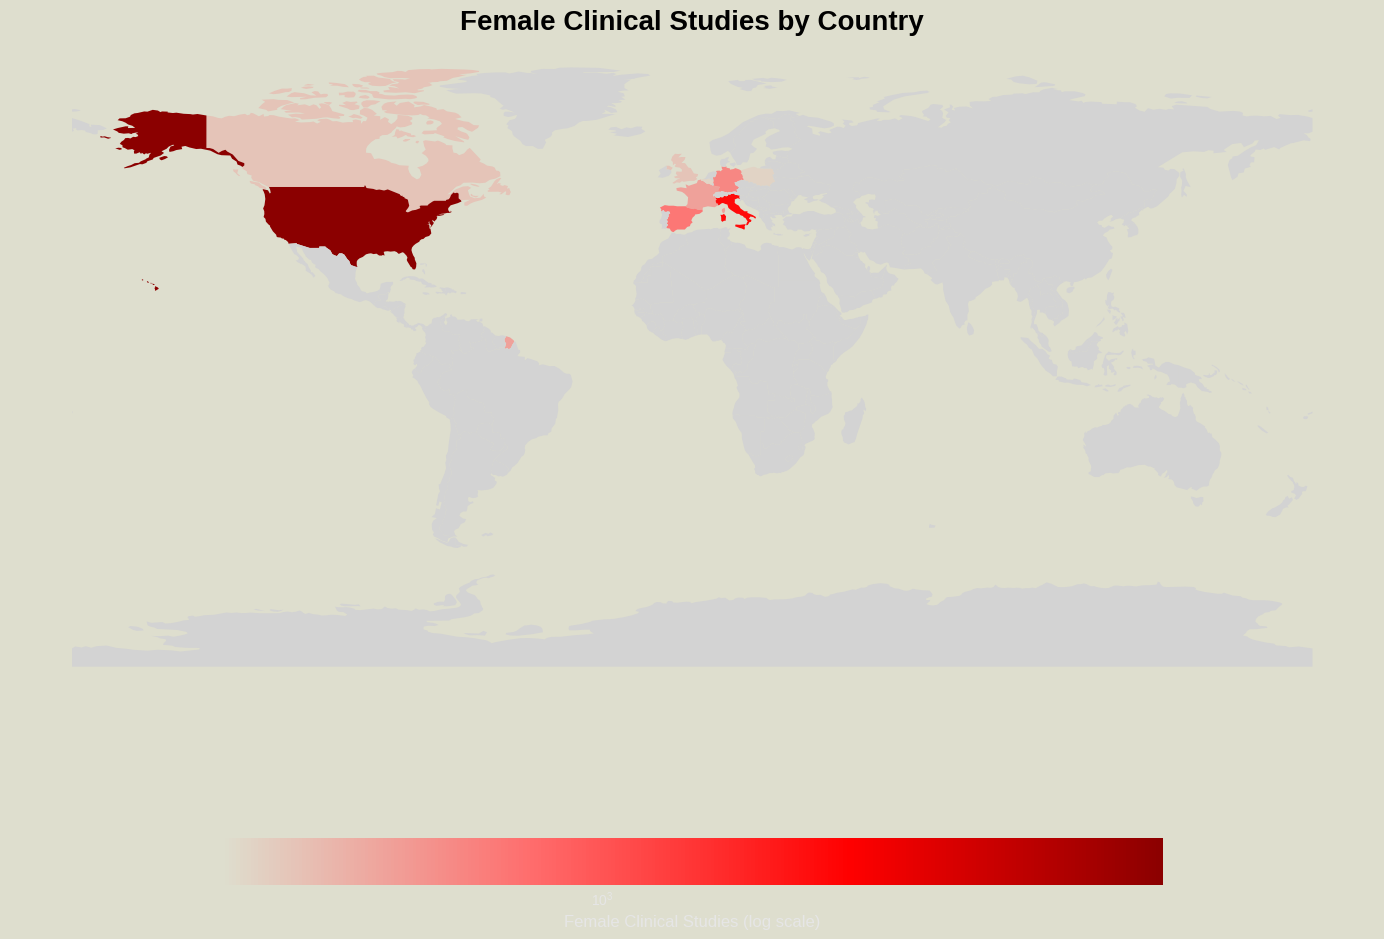

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
import urllib.request
import os
import numpy as np

df = pd.read_csv(os.path.join(resultPath, "mongo_6.csv"))

country_mapping = {
    'united states': 'united states of america',
    'russian federation': 'russia',
    'czechia': 'czech republic',
    'macedonia, the former yugoslav republic of': 'north macedonia',
    'holy see (vatican city state)': 'vatican city',
    'south korea': 'korea, republic of',
    'swaziland': 'eswatini',
    'brunei darussalam': 'brunei',
    'taiwan': 'taiwan, province of china'
}

df['Paese'] = df['Paese'].replace(country_mapping)
df = df.groupby('Paese', as_index=False).sum()

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

world = world.rename(columns={'ADMIN': 'Nation_Mapped'})
world['Nation_Mapped'] = world['Nation_Mapped'].astype(str).str.lower()
world['geometry'] = world['geometry'].simplify(0.05)

df['Nation_Mapped'] = df['Paese']
merged = world.set_index('Nation_Mapped').join(df.set_index('Nation_Mapped'))
merged.reset_index(inplace=True)

cmap = LinearSegmentedColormap.from_list("custom_cmap", ['#dedece', '#ff6b6b', '#ff0000', '#8b0000'])
non_zero_female_studies = df['Numero Studi'][df['Numero Studi'] > 0]
vmin = non_zero_female_studies.min() if not non_zero_female_studies.empty else 1
norm = LogNorm(vmin=vmin, vmax=df['Numero Studi'].max())

plt.style.use(style_path)

fig, ax = plt.subplots(figsize=(16, 10))
fig.patch.set_facecolor('#dedece')
ax.set_facecolor('#dedece')

merged.plot(
    column='Numero Studi',
    ax=ax,
    cmap=cmap,
    norm=norm,
    legend=True,
    missing_kwds={'color': 'lightgrey', 'label': 'No data available'},
    legend_kwds={'label': "Female Clinical Studies (log scale)", 'orientation': "horizontal", 'shrink': 0.6}
)

ax.set_title("Female Clinical Studies by Country", fontsize=20, fontweight='bold', color='black')
ax.axis('off')

world_proj = world.to_crs(epsg=3857)

plt.tight_layout()
image_file = os.path.join(output_path, "mongo_6.png")
plt.savefig(image_file, dpi=300, facecolor=fig.get_facecolor())

plt.show()

7.

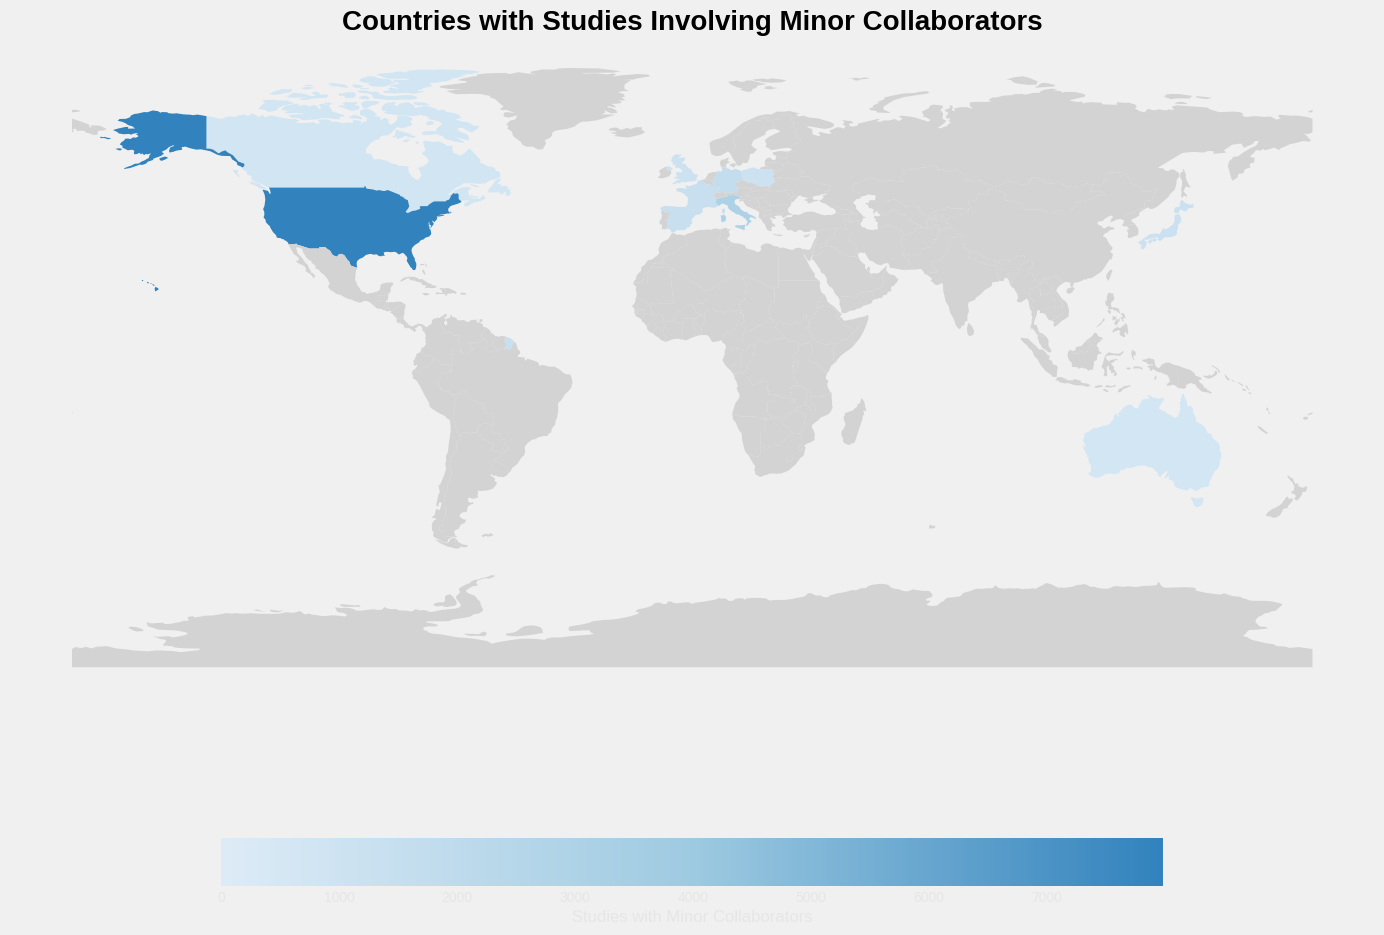

In [ ]:
from matplotlib.colors import LinearSegmentedColormap, Normalize

df = pd.read_csv(os.path.join(resultPath, "mongo_7.csv"))

country_mapping = {
    'united states': 'united states of america',
    'russian federation': 'russia',
    'czechia': 'czech republic',
    'macedonia, the former yugoslav republic of': 'north macedonia',
    'holy see (vatican city state)': 'vatican city',
    'south korea': 'korea, republic of',
    'swaziland': 'eswatini',
    'brunei darussalam': 'brunei',
    'taiwan': 'taiwan, province of china'
}

df['Paese'] = df['Paese'].replace(country_mapping)
df = df.groupby('Paese', as_index=False).sum()

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

world = world.rename(columns={'ADMIN': 'Nation_Mapped'})
world['Nation_Mapped'] = world['Nation_Mapped'].astype(str).str.lower()
world['geometry'] = world['geometry'].simplify(0.05)

df['Nation_Mapped'] = df['Paese']
merged = world.set_index('Nation_Mapped').join(df.set_index('Nation_Mapped'))
merged.reset_index(inplace=True)

cmap = LinearSegmentedColormap.from_list("custom_cmap", ['#deebf7', '#9ecae1', '#3182bd'])
norm = Normalize(vmin=0, vmax=df['Numero Studi'].max())

plt.style.use(style_path)

fig, ax = plt.subplots(figsize=(16, 10))
fig.patch.set_facecolor('#f0f0f0')
ax.set_facecolor('#f0f0f0')

merged.plot(
    column='Numero Studi',
    ax=ax,
    cmap=cmap,
    norm=norm,
    legend=True,
    missing_kwds={'color': 'lightgrey', 'label': 'No data available'},
    legend_kwds={'label': "Studies with Minor Collaborators", 'orientation': "horizontal", 'shrink': 0.6}
)

ax.set_title("Countries with Studies Involving Minor Collaborators", fontsize=20, fontweight='bold', color='black')
ax.axis('off')

plt.tight_layout()
image_file = os.path.join(output_path, "mongo_7.png")
plt.savefig(image_file, dpi=300, facecolor=fig.get_facecolor())

plt.show()

8.

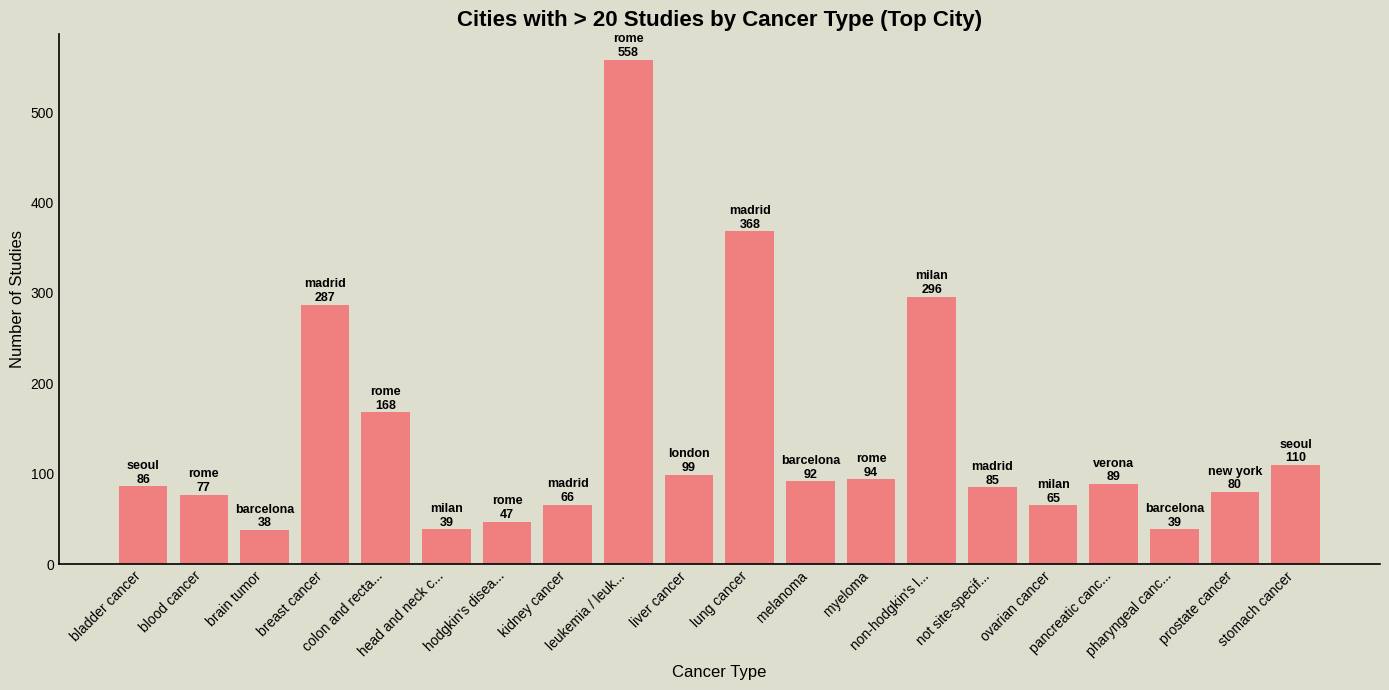

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

df = pd.read_csv(os.path.join(resultPath, "mongo_8.csv"))

df_sorted = df.sort_values(by=['Tipo di Cancro', 'Studi in Top Città'], ascending=[True, False])

threshold = 20

df_filtered = df_sorted[df_sorted['Studi in Top Città'] > threshold].copy()

max_len = 15
df_filtered['Cancer Type Abbreviated'] = df_filtered['Tipo di Cancro'].apply(
    lambda x: x[:max_len] + '...' if len(x) > max_len else x
)

plt.style.use(style_path)

fig, ax = plt.subplots(figsize=(14, 7))
bar_color = 'lightcoral'
bars = ax.bar(df_filtered["Cancer Type Abbreviated"], df_filtered["Studi in Top Città"], color=bar_color)
fig.patch.set_facecolor('#dedece')
ax.set_facecolor('#dedece')

for bar, city, val in zip(bars, df_filtered["Top Città"], df_filtered["Studi in Top Città"]):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.5,
            f"{city}\n{int(val)}",
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='black')

ax.set_title(f"Cities with > {threshold} Studies by Cancer Type (Top City)", fontsize=16, fontweight='bold', color='black')
ax.set_ylabel("Number of Studies", fontsize=12, color='black')
ax.set_xlabel("Cancer Type", fontsize=12, color='black')

ax.grid(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

ax.tick_params(axis='y', labelsize=10, labelcolor='black')
plt.xticks(rotation=45, ha='right', fontsize=10, color='black')

plt.tight_layout()
image_file = os.path.join(output_path, "mongo_8.png")
plt.savefig(image_file, dpi=300, facecolor=fig.get_facecolor())

plt.show()

10.

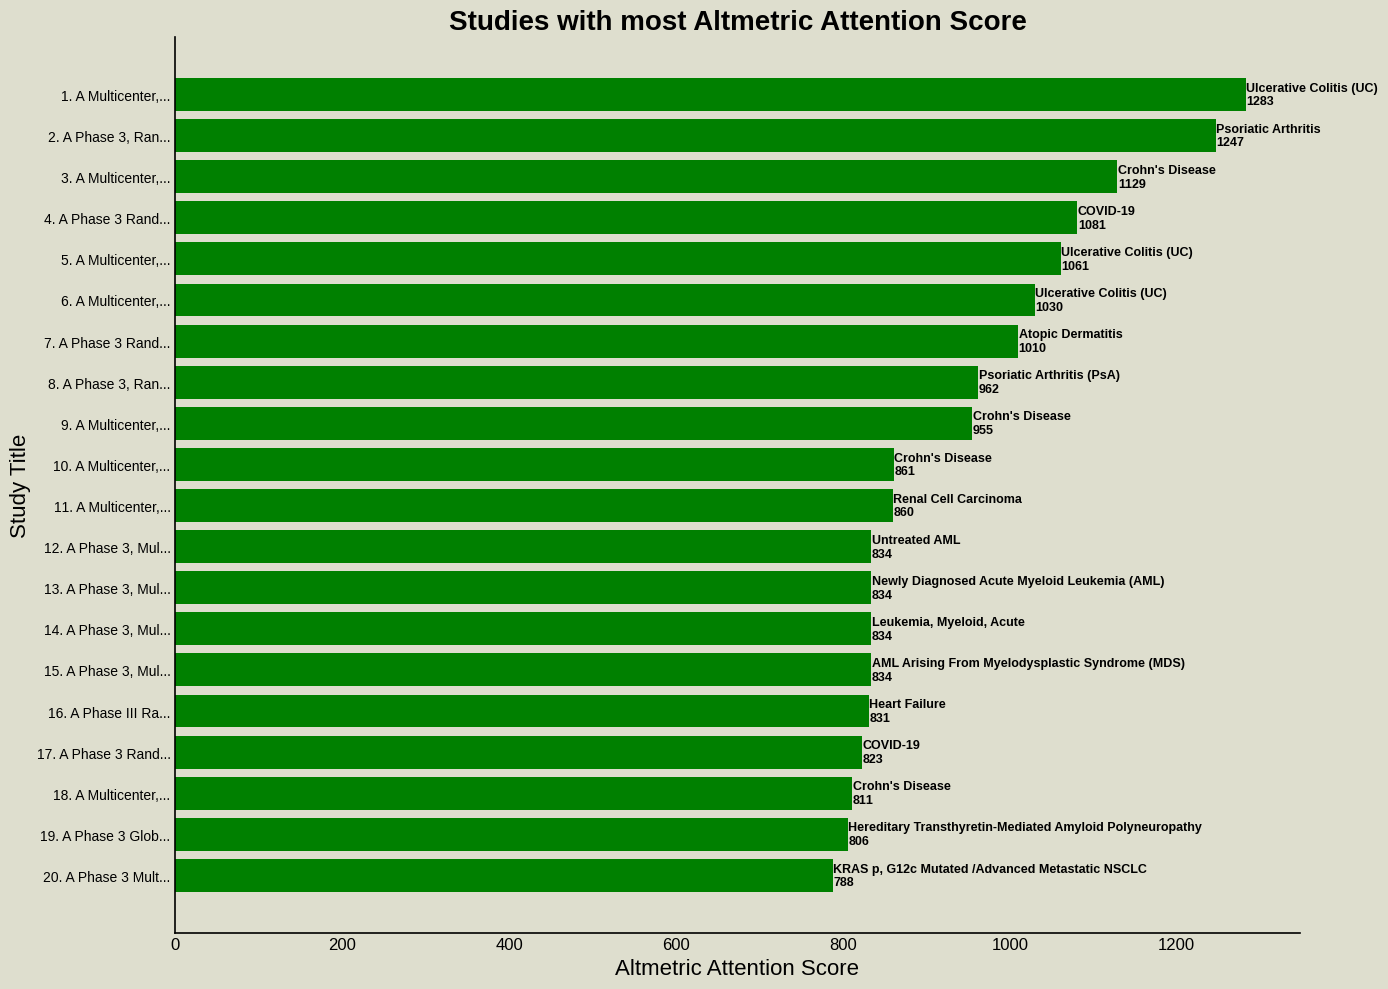

In [ ]:
df = pd.read_csv(os.path.join(resultPath, "mongo_10.csv"))

top_20 = df.head(20)

plt.style.use(style_path)

top_20 = top_20.sort_values('Altmetric Score')

max_len = 20
top_20['Short Title'] = [
    f"{20-(i)}. {t if len(t) <= max_len else t[:max_len - 6] + '...'}"
    for i, t in enumerate(top_20['Title'])
]

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('#dedece')
ax.set_facecolor('#dedece')

bars = ax.barh(top_20['Short Title'], top_20['Altmetric Score'], color='green')

for bar, condition, val in zip(bars, top_20["Condtion"], top_20["Altmetric Score"]):
    xval = bar.get_width()
    ax.text(xval + 0.5,
            bar.get_y() + bar.get_height()/2,
            f"{condition}\n{int(val)}",
            ha='left',
            va='center',
            fontsize=9,
            fontweight='bold',
            color='black')

ax.grid(False)

ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

ax.set_title("Studies with most Altmetric Attention Score", fontsize=20, fontweight='bold', color='black')

ax.set_xlabel("Altmetric Attention Score", fontsize=16, color='black')
ax.set_ylabel("Study Title", fontsize=16, color='black')

ax.tick_params(axis='x', labelsize=12, labelcolor='black')
ax.tick_params(axis='y', labelsize=10, labelcolor='black')

plt.tight_layout()

image_file = os.path.join(output_path, "mongo_10.png")
plt.savefig(image_file, dpi=300, facecolor=fig.get_facecolor())

plt.show()

11.

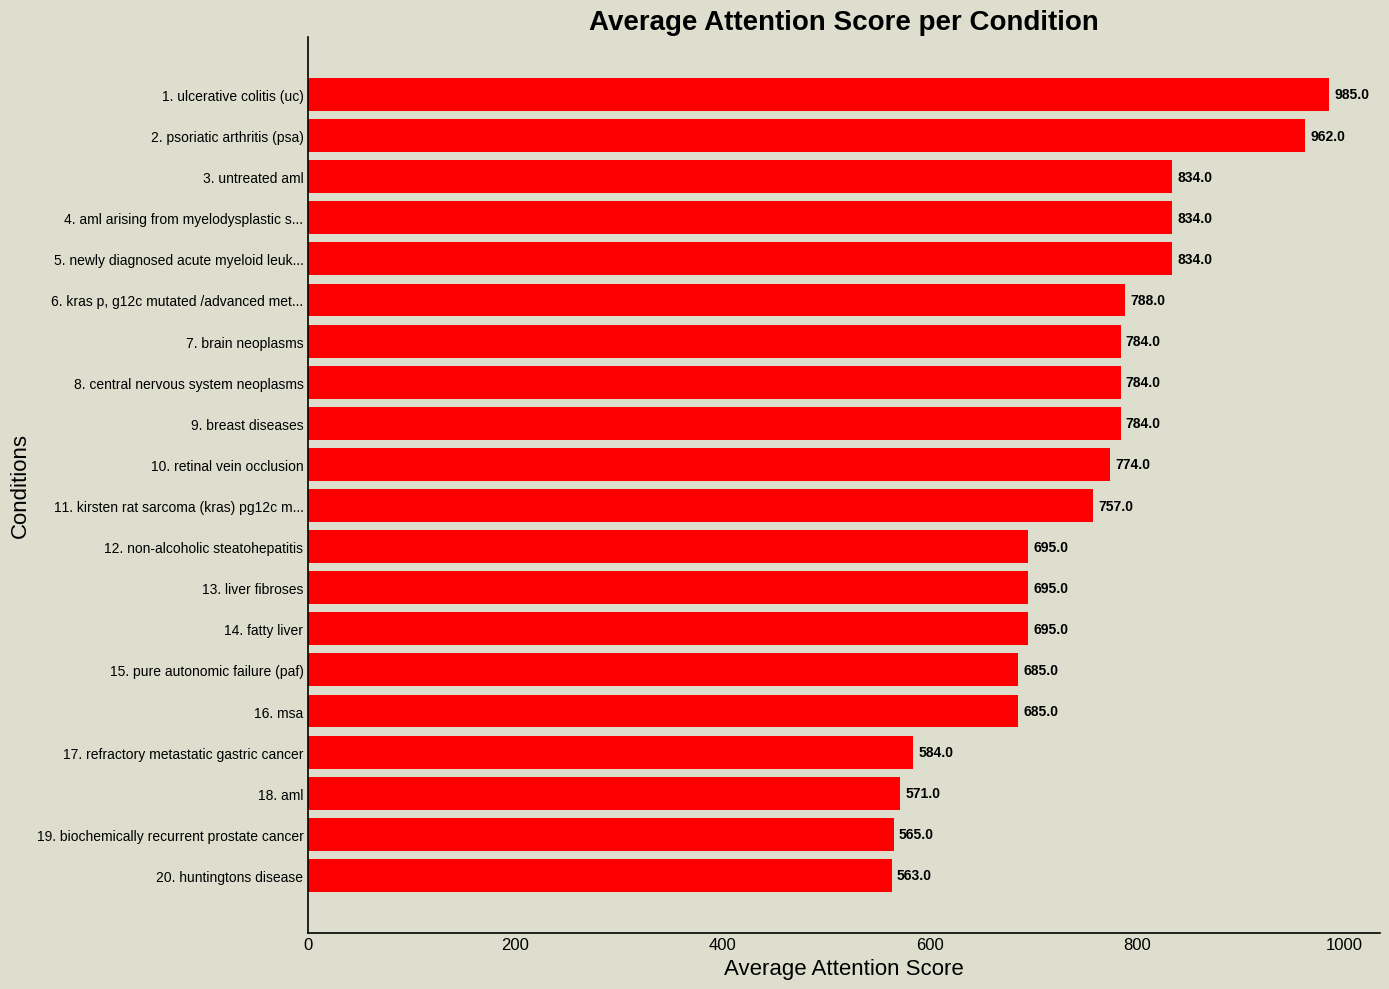

In [ ]:
df = pd.read_csv(os.path.join(resultPath, "mongo_11.csv"))

top_20 = df.head(20)

plt.style.use(style_path)

top_20 = top_20.sort_values('Average Altmetric Score')

max_len = 40
top_20['Short Condition'] = [
    f"{20-(i)}. {t if len(t) <= max_len else t[:max_len - 6] + '...'}"
    for i, t in enumerate(top_20['Condition'])
]

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('#dedece')
ax.set_facecolor('#dedece')

bars = ax.barh(top_20['Short Condition'], top_20['Average Altmetric Score'], color='red')

for i, v in enumerate(top_20['Average Altmetric Score']):
    ax.text(v + 5, i, f'{v:.1f}', va='center', fontsize=10, color='black', fontweight='bold')

ax.grid(False)

ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

ax.set_title("Average Attention Score per Condition", fontsize=20, fontweight='bold', color='black')

ax.set_xlabel("Average Attention Score", fontsize=16, color='black')
ax.set_ylabel("Conditions", fontsize=16, color='black')

ax.tick_params(axis='x', labelsize=12, labelcolor='black')
ax.tick_params(axis='y', labelsize=10, labelcolor='black')

plt.tight_layout()

image_file = os.path.join(output_path, "mongo_11.png")
plt.savefig(image_file, dpi=300, facecolor=fig.get_facecolor())

plt.show()

13

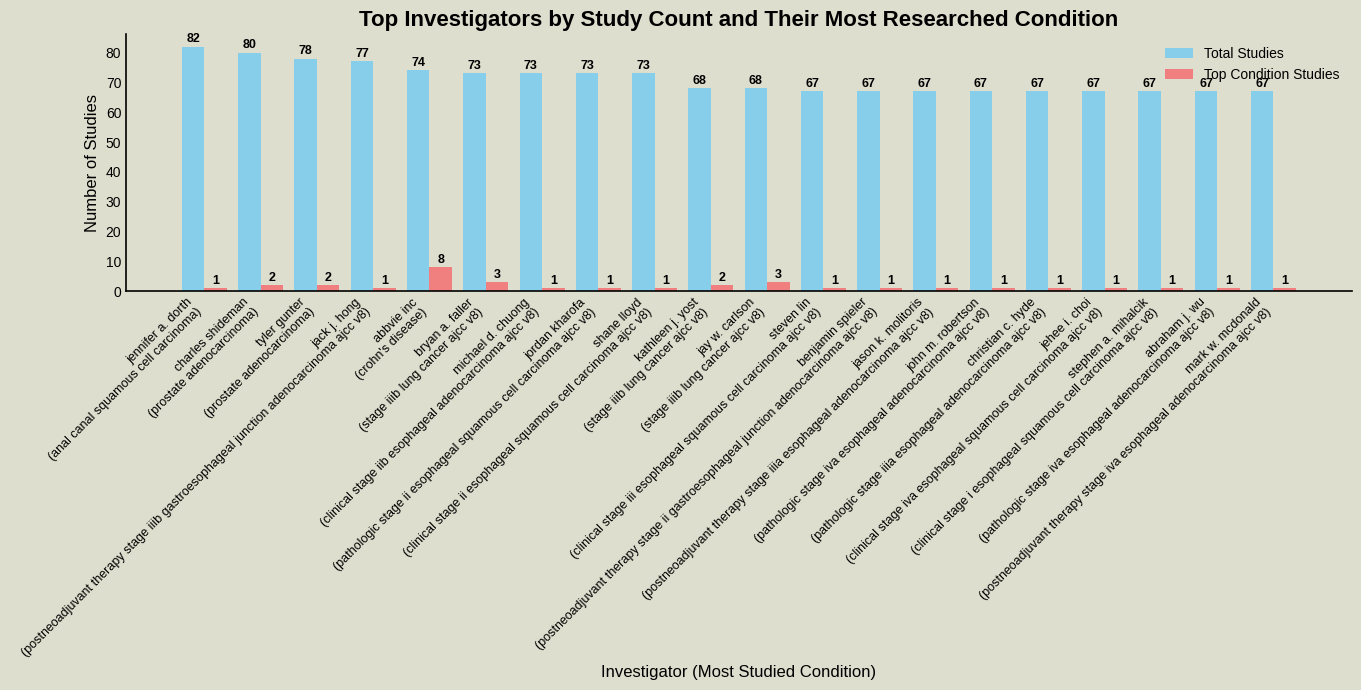

In [ ]:
df = pd.read_csv(os.path.join(resultPath, "mongo_13.csv"))
df = df.head(20)

bar_width = 0.4
x = np.arange(len(df))

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#dedece')
ax.set_facecolor('#dedece')

bars1 = ax.bar(x - bar_width/2, df["Total Studies"], width=bar_width, label="Total Studies", color='skyblue')
bars2 = ax.bar(x + bar_width/2, df["Studies for Top Condition"], width=bar_width, label="Top Condition Studies", color='lightcoral')

for bars in [bars1, bars2]:
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.5,
                f"{int(yval)}", ha='center', va='bottom',
                fontsize=9, fontweight='bold', color='black')

df["XLabel"] = df["Investigator"] + "\n(" + df["Top Condition"] + ")"

ax.set_xticks(x)
ax.set_xticklabels(df["XLabel"], rotation=45, ha='right', fontsize=9, color='black')

ax.tick_params(axis='y', labelsize=10, labelcolor='black')
ax.yaxis.set_visible(True)

ax.set_title("Top Investigators by Study Count and Their Most Researched Condition",
             fontsize=16, fontweight='bold', color='black')
ax.set_ylabel("Number of Studies", fontsize=12, color='black')
ax.set_xlabel("Investigator (Most Studied Condition)", fontsize=12, color='black')

legend = ax.legend()
for text in legend.get_texts():
    text.set_color("black")

ax.grid(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

plt.tight_layout()

image_file = os.path.join(output_path, "mongo_13.png")
plt.savefig(image_file, dpi=300, facecolor=fig.get_facecolor())

plt.show()

14.

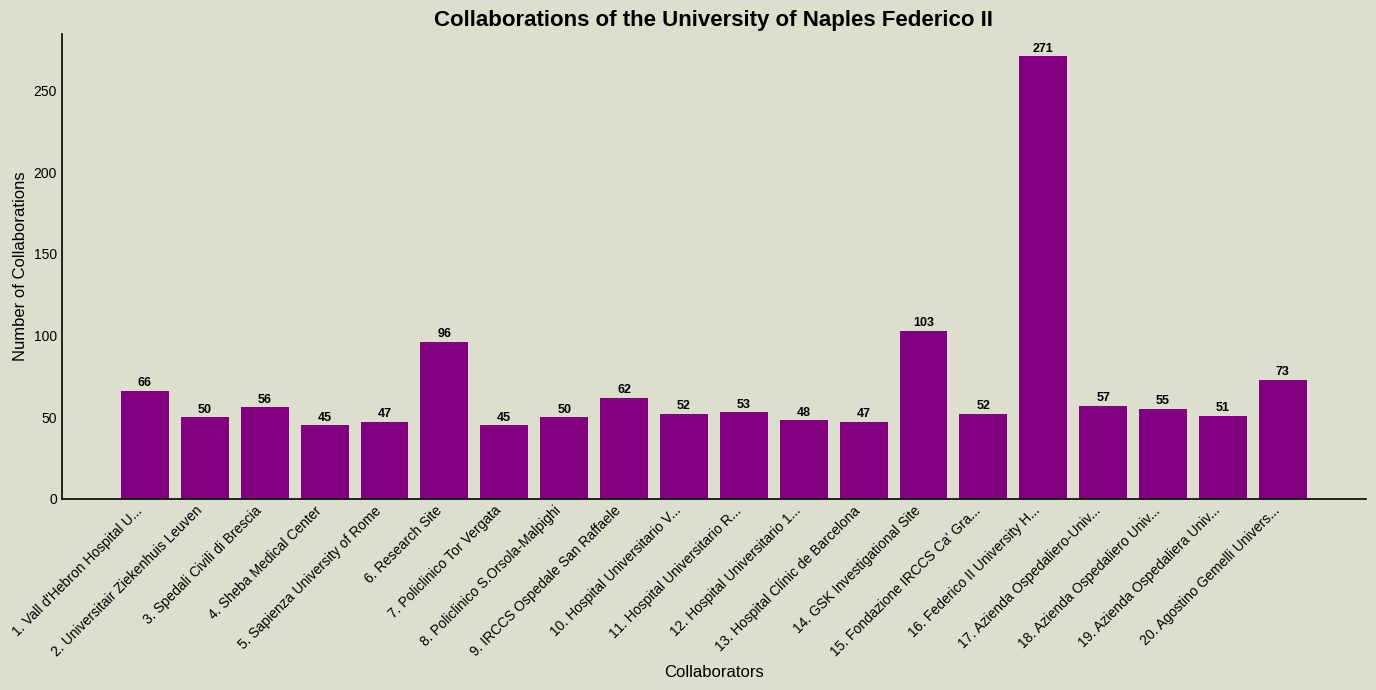

In [ ]:
df = pd.read_csv(os.path.join(resultPath, "mongo_14.csv"))

df = df.head(20)

df_sorted = df.sort_values(by=['Sponsor/Collaborator', 'Number of Collaborations'], ascending=[False, True])

max_len = 30
df_sorted['Collaborator Abbreviated'] = [
    f"{i+1}. {t if len(t) <= max_len else t[:max_len - 6] + '...'}"
    for i, t in enumerate(df_sorted['Sponsor/Collaborator'])
]

plt.style.use(style_path)

fig, ax = plt.subplots(figsize=(14, 7))
bar_color = 'purple'
bars = ax.bar(df_sorted["Collaborator Abbreviated"], df_sorted["Number of Collaborations"], color=bar_color)
fig.patch.set_facecolor('#dedece')
ax.set_facecolor('#dedece')

for i, val in enumerate(df_sorted["Number of Collaborations"]):
    ax.text(i, val + 1,
            f"{int(val)}",
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='black')

ax.set_title(f"Collaborations of the University of Naples Federico II", fontsize=16, fontweight='bold', color='black')
ax.set_ylabel("Number of Collaborations", fontsize=12, color='black')
ax.set_xlabel("Collaborators", fontsize=12, color='black')

ax.grid(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

ax.tick_params(axis='y', labelsize=10, labelcolor='black')
plt.xticks(rotation=45, ha='right', fontsize=10, color='black')

plt.tight_layout()
image_file = os.path.join(output_path, "mongo_14.png")
plt.savefig(image_file, dpi=300, facecolor=fig.get_facecolor())

plt.show()

16.

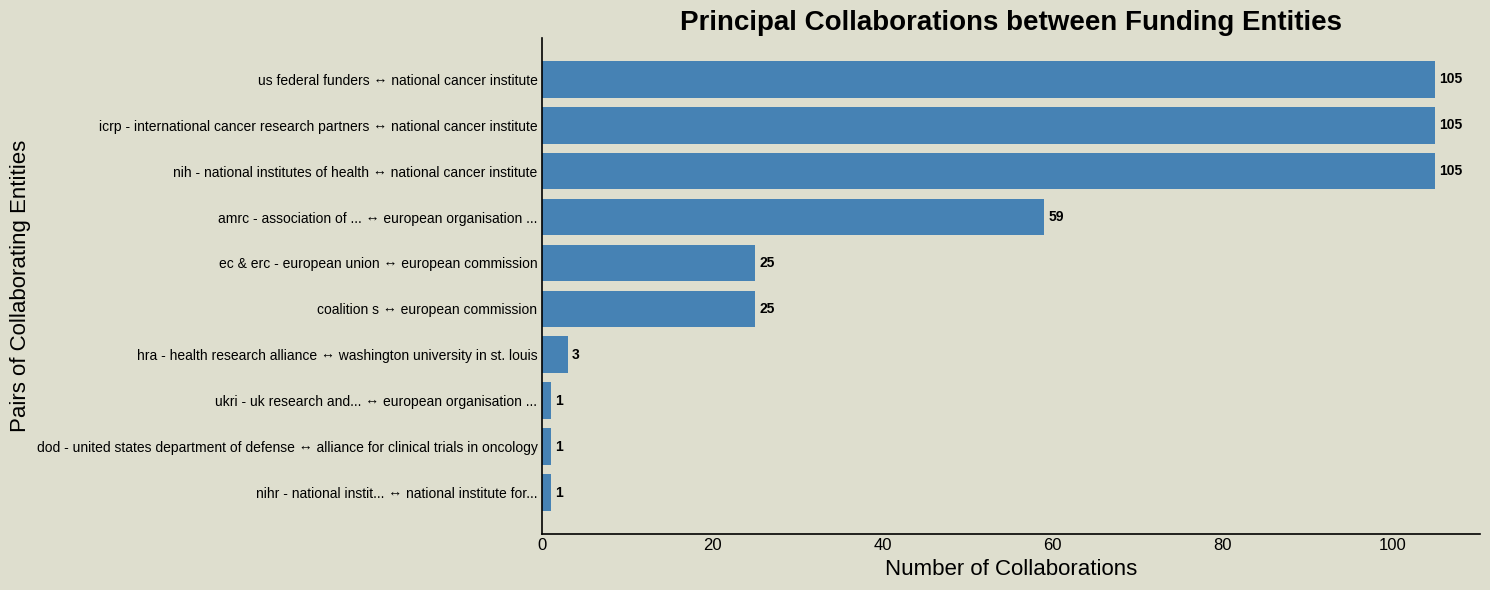

In [ ]:
df = pd.read_csv(os.path.join(resultPath, "mongo_16.csv"))

plt.style.use(style_path)

df_sorted = df.sort_values('Number of Collaborations')

max_len = 45
df_sorted["Pair"] = [
    f"{main[:max_len]} ↔ {collab[:max_len]}" if len(main) + len(collab) <= max_len * 2
    else f"{main[:max_len//2]}... ↔ {collab[:max_len//2]}..."
    for main, collab in zip(df_sorted["Main Funder Group"], df_sorted["Top Collaborating Funder"])
]

fig, ax = plt.subplots(figsize=(15, max(6, 0.4 * len(df_sorted))))
fig.patch.set_facecolor('#dedece')
ax.set_facecolor('#dedece')

bars = ax.barh(df_sorted["Pair"], df_sorted["Number of Collaborations"], color='steelblue')

for i, v in enumerate(df_sorted["Number of Collaborations"]):
    ax.text(v + 0.5, i, str(v), va='center', fontsize=10, color='black', fontweight='bold')

ax.set_title("Principal Collaborations between Funding Entities", fontsize=20, fontweight='bold', color='black')

ax.set_xlabel("Number of Collaborations", fontsize=16, color='black')
ax.set_ylabel("Pairs of Collaborating Entities", fontsize=16, color='black')

ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

ax.tick_params(axis='x', labelsize=12, labelcolor='black')
ax.tick_params(axis='y', labelsize=10, labelcolor='black')

ax.grid(False)

plt.tight_layout()

output_file = os.path.join(output_path, "mongo_16.png")
plt.savefig(output_file, dpi=300, facecolor=fig.get_facecolor())

plt.show()
